In [70]:
import pandas as pd 
import seaborn as sns 
import plotly as px 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_excel(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Wine + covid.xlsx",sheet_name =1, header = 1)

In [9]:
df.isnull().sum()

age          0
gender       0
fever        0
cough        0
city         0
has_covid    0
dtype: int64

In [8]:
df["fever"] = df["fever"].fillna(df["fever"].mean())

In [12]:
df.sample(5)

,age,gender,fever,cough,city,has_covid
21,73,Male,98.0,Mild,Bangalore,Yes
27,33,Female,102.0,Strong,Delhi,No
14,51,Male,104.0,Mild,Bangalore,No
17,40,Female,98.0,Strong,Delhi,No
64,42,Male,104.0,Mild,Mumbai,No


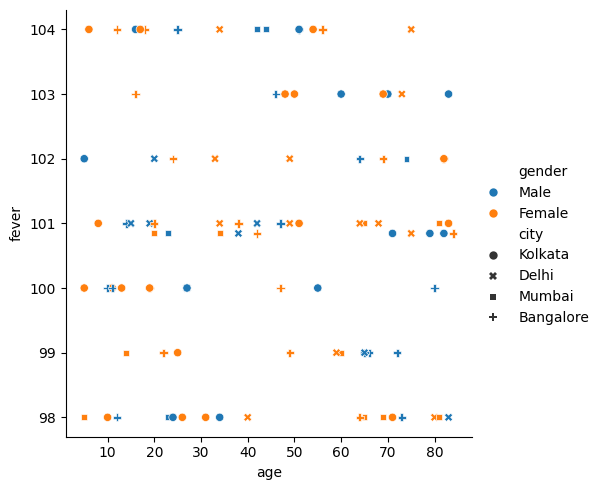

In [15]:
sns.relplot(data = df , x = "age" , y ="fever" , kind = "scatter" , hue = "gender", style = "city")

<Axes: xlabel='age', ylabel='fever'>

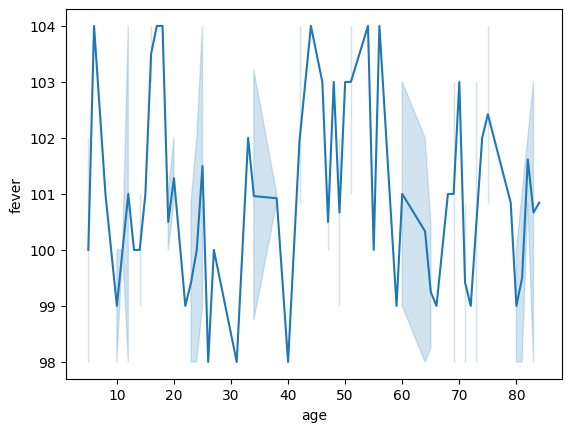

In [16]:
sns.lineplot(data = df , x = "age" , y = "fever")

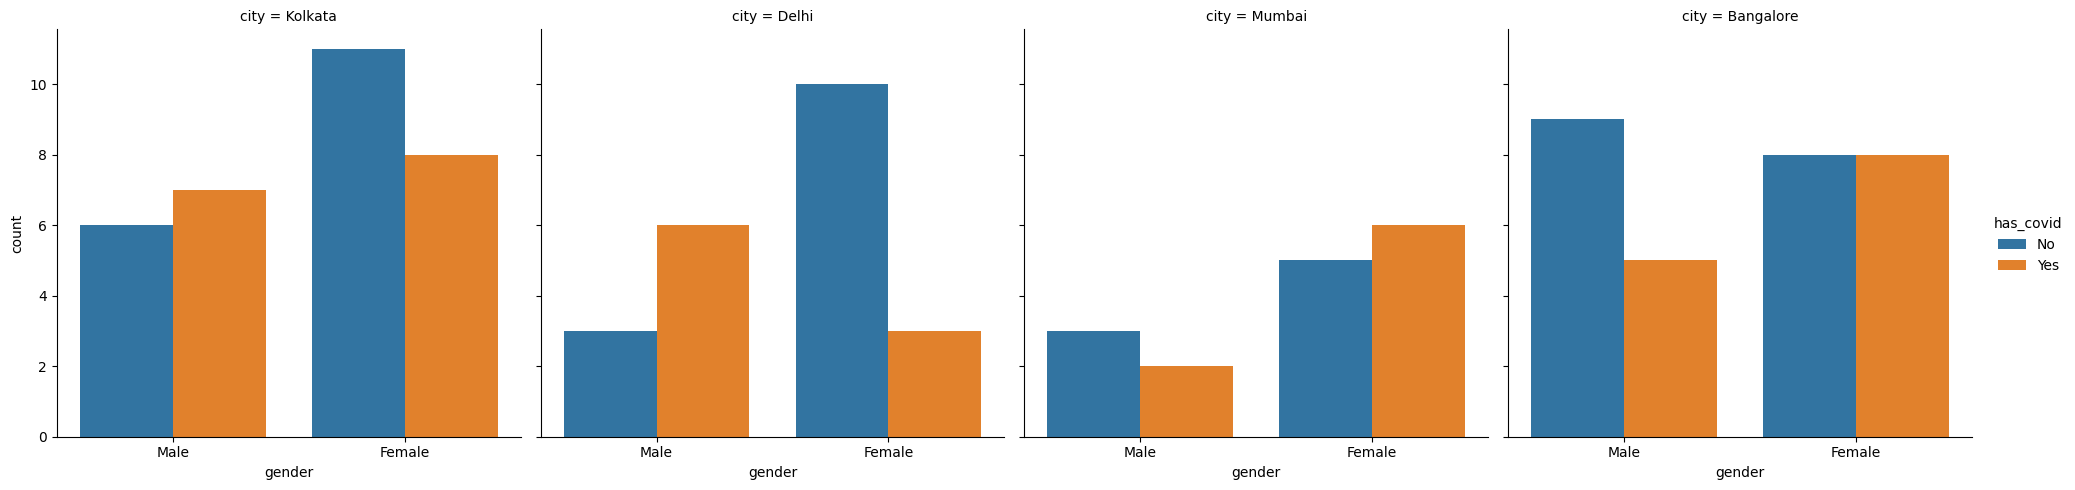

In [23]:
sns.catplot(data = df , x= "gender" , kind = "count", hue = "has_covid", col = "city")

In [24]:
df

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No
...,...,...,...,...,...,...
95,12,Female,104.0,Mild,Bangalore,No
96,51,Female,101.0,Strong,Kolkata,Yes
97,20,Female,101.0,Mild,Bangalore,No
98,5,Female,98.0,Strong,Mumbai,No


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X_train , X_test , y_train , y_test = train_test_split(df.iloc[:,0:5] , df.iloc[:,5], test_size  = 0.25, random_state = 42)

In [29]:
from sklearn.preprocessing import MinMaxScaler

In [30]:
MM = MinMaxScaler() 

In [36]:
MM.fit(X_train[["age" , "fever"]])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [40]:
X_trained =MM.transform(X_train[["age" , "fever"]])
X_tested = MM.transform(X_test[["age" , "fever"]])

In [45]:
X_trained  = pd.DataFrame(X_trained , columns = ("age" , "fever"))

In [55]:
df.drop(columns = ["age" , "fever"], inplace =True )

In [66]:
df[["T_age", "T_fever"]] = MM.transform(df[["age" , "fever"]])

In [67]:
df

,age,gender,fever,cough,city,has_covid,T_age,T_fever
0,60,Male,103.0,Mild,Kolkata,No,0.696203,0.833333
1,27,Male,100.0,Mild,Delhi,Yes,0.278481,0.333333
2,42,Male,101.0,Mild,Delhi,No,0.468354,0.500000
3,31,Female,98.0,Mild,Kolkata,No,0.329114,0.000000
4,65,Female,101.0,Mild,Mumbai,No,0.759494,0.500000
...,...,...,...,...,...,...,...,...
95,12,Female,104.0,Mild,Bangalore,No,0.088608,1.000000
96,51,Female,101.0,Strong,Kolkata,Yes,0.582278,0.500000
97,20,Female,101.0,Mild,Bangalore,No,0.189873,0.500000
98,5,Female,98.0,Strong,Mumbai,No,0.000000,0.000000


In [57]:
from sklearn.preprocessing import OneHotEncoder

In [59]:
OHE = OneHotEncoder(drop = "first" ,  sparse_output = False)

In [68]:
OHE.fit(df[["city"]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_ca

In [69]:
encoded = OHE.transform(df[["city"]])

In [71]:
df

,age,gender,fever,cough,city,has_covid,T_age,T_fever
0,60,Male,103.0,Mild,Kolkata,No,0.696203,0.833333
1,27,Male,100.0,Mild,Delhi,Yes,0.278481,0.333333
2,42,Male,101.0,Mild,Delhi,No,0.468354,0.500000
3,31,Female,98.0,Mild,Kolkata,No,0.329114,0.000000
4,65,Female,101.0,Mild,Mumbai,No,0.759494,0.500000
...,...,...,...,...,...,...,...,...
95,12,Female,104.0,Mild,Bangalore,No,0.088608,1.000000
96,51,Female,101.0,Strong,Kolkata,Yes,0.582278,0.500000
97,20,Female,101.0,Mild,Bangalore,No,0.189873,0.500000
98,5,Female,98.0,Strong,Mumbai,No,0.000000,0.000000


In [79]:
df  = pd.get_dummies(df, columns =["city"] ,dtype = int, drop_first = True )

In [83]:
df.drop(columns = ["age", "fever"])

,gender,cough,has_covid,T_age,T_fever,city_Delhi,city_Kolkata,city_Mumbai
0,Male,Mild,No,0.696203,0.833333,0,1,0
1,Male,Mild,Yes,0.278481,0.333333,1,0,0
2,Male,Mild,No,0.468354,0.500000,1,0,0
3,Female,Mild,No,0.329114,0.000000,0,1,0
4,Female,Mild,No,0.759494,0.500000,0,0,1
...,...,...,...,...,...,...,...,...
95,Female,Mild,No,0.088608,1.000000,0,0,0
96,Female,Strong,Yes,0.582278,0.500000,0,1,0
97,Female,Mild,No,0.189873,0.500000,0,0,0
98,Female,Strong,No,0.000000,0.000000,0,0,1


In [84]:
from sklearn.preprocessing import OrdinalEncoder

In [85]:
df["cough"].value_counts()

cough
Mild      62
Strong    38
Name: count, dtype: int64

In [90]:
OE = OrdinalEncoder(categories = [["Mild", "Strong"]])

In [91]:
OE.fit(df[["cough"]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['Mild', 'Strong']]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [92]:
df["T_cough"] = OE.transform(df[["cough"]])

In [99]:
df.drop(columns = ["age" , "fever"], inplace = True)

In [100]:
df

,gender,has_covid,T_age,T_fever,city_Delhi,city_Kolkata,city_Mumbai,T_cough
0,Male,No,0.696203,0.833333,0,1,0,0.0
1,Male,Yes,0.278481,0.333333,1,0,0,0.0
2,Male,No,0.468354,0.500000,1,0,0,0.0
3,Female,No,0.329114,0.000000,0,1,0,0.0
4,Female,No,0.759494,0.500000,0,0,1,0.0
...,...,...,...,...,...,...,...,...
95,Female,No,0.088608,1.000000,0,0,0,0.0
96,Female,Yes,0.582278,0.500000,0,1,0,1.0
97,Female,No,0.189873,0.500000,0,0,0,0.0
98,Female,No,0.000000,0.000000,0,0,1,1.0


In [101]:
import numpy as np 

In [106]:
np.random.seed(42)
data = {
"age" : np.random.randint(20,60,20),
"gender": np.random.choice(["Male", "Female"],20),
"Job" : np.random.choice(["Analyst", "Software Engineer", "Sales"],20),
"salary" : np.random.randint(10000,50000,20)
    
}

df1 = pd.DataFrame(data)
df1

,age,gender,Job,salary
0,58,Female,Sales,21016
1,48,Female,Software Engineer,33897
2,34,Female,Software Engineer,12612
3,27,Male,Sales,33483
4,40,Male,Software Engineer,27159
5,58,Female,Sales,24541
6,38,Female,Sales,45920
7,42,Female,Analyst,36531
8,30,Male,Sales,11585
9,30,Female,Analyst,13943


In [110]:
df1.groupby("Job")["salary"].sum()

Job
Analyst              100021
Sales                223358
Software Engineer    166261
Name: salary, dtype: int32

In [113]:
round(df1.groupby("gender")["salary"].mean(),2)

gender
Female    24827.17
Male      23964.25
Name: salary, dtype: float64

In [73]:
df = pd.read_excel(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Wine + covid.xlsx", sheet_name =1 , header =1 )

In [51]:
X_train , X_test , y_train , y_test = train_test_split(df3.iloc[:,0:5] , df3.iloc[:,-1], test_size = 0.25 , random_state = 42)

In [121]:
X_train 

,age,gender,fever,cough,city
15,70,Male,103.0,Strong,Kolkata
40,49,Female,102.0,Mild,Delhi
96,51,Female,101.0,Strong,Kolkata
9,64,Female,101.0,Mild,Delhi
72,83,Female,101.0,Mild,Kolkata
...,...,...,...,...,...
60,24,Female,102.0,Strong,Bangalore
71,75,Female,104.0,Strong,Delhi
14,51,Male,104.0,Mild,Bangalore
92,82,Female,102.0,Strong,Kolkata


In [122]:
from sklearn.compose import ColumnTransformer

In [123]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder 
from sklearn.preprocessing import OrdinalEncoder 

In [126]:
transformer = ColumnTransformer(transformers = [
("First" , SimpleImputer(), ["fever"]),
("Second" , OrdinalEncoder(categories = [["Mild", "Strong"]]) , ["cough"]) ,
("Third" , OneHotEncoder(drop = "first" , sparse_output = False) , ["city"])], remainder = "passthrough")


In [128]:
transformer.fit_transform(X_train)

array([[103.0, 1.0, 0.0, 1.0, 0.0, 70, 'Male'],
       [102.0, 0.0, 1.0, 0.0, 0.0, 49, 'Female'],
       [101.0, 1.0, 0.0, 1.0, 0.0, 51, 'Female'],
       [101.0, 0.0, 1.0, 0.0, 0.0, 64, 'Female'],
       [101.0, 0.0, 0.0, 1.0, 0.0, 83, 'Female'],
       [98.0, 0.0, 0.0, 0.0, 1.0, 65, 'Female'],
       [104.0, 0.0, 0.0, 0.0, 0.0, 18, 'Female'],
       [103.0, 0.0, 0.0, 0.0, 0.0, 16, 'Female'],
       [104.0, 0.0, 0.0, 1.0, 0.0, 16, 'Male'],
       [100.0, 0.0, 0.0, 1.0, 0.0, 27, 'Male'],
       [101.01515151515152, 0.0, 0.0, 0.0, 0.0, 84, 'Female'],
       [104.0, 0.0, 0.0, 1.0, 0.0, 51, 'Male'],
       [102.0, 0.0, 0.0, 0.0, 0.0, 69, 'Female'],
       [102.0, 1.0, 0.0, 0.0, 0.0, 82, 'Female'],
       [103.0, 0.0, 0.0, 1.0, 0.0, 69, 'Female'],
       [104.0, 0.0, 0.0, 0.0, 1.0, 44, 'Male'],
       [102.0, 0.0, 0.0, 0.0, 1.0, 74, 'Male'],
       [101.01515151515152, 1.0, 0.0, 0.0, 1.0, 20, 'Female'],
       [104.0, 0.0, 0.0, 0.0, 0.0, 12, 'Female'],
       [102.0, 1.0, 1.0, 0.0, 0.0, 33

In [6]:
import pandas as pd
import numpy as np 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder 
from sklearn.preprocessing import OrdinalEncoder 

In [101]:
df = pd.read_excel(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Wine + covid.xlsx",sheet_name =1, header = 1)
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [6]:
from sklearn.preprocessing import MinMaxScaler

In [7]:
MM = MinMaxScaler()

In [8]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(df.iloc[:,0:5],df.iloc[:,-1], test_size = 0.3 , random_state = 42)

In [11]:
MM.fit(X_train[["age","fever"]])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [16]:
X_train["age"] = X_train["age"].fillna(X_train["age"].mean())

In [17]:
X_train.isnull().sum()

age       0
gender    0
fever     9
cough     0
city      0
dtype: int64

In [18]:
X_train["fever"] = X_train["fever"].fillna(X_train["fever"].mean())

In [19]:
X_trained = MM.transform(X_train[["age","fever"]])

In [22]:
X_trained = pd.DataFrame(X_trained, columns = ["Age" , "fever"])
X_trained 

,Age,fever
0,0.759494,0.000000
1,0.164557,1.000000
2,0.139241,0.833333
3,0.139241,1.000000
4,0.278481,0.333333
...,...,...
65,0.240506,0.666667
66,0.886076,1.000000
67,0.582278,1.000000
68,0.974684,0.666667


In [26]:
X_train.drop(columns = ["age" , "fever"], inplace = True)

In [29]:
X_train["Age"] = X_trained["Age"]

In [31]:
X_train["Fever"] = X_trained["fever"]

In [38]:
OE = OrdinalEncoder(categories = [["Mild", "Strong"]])

In [41]:
cough_OE = OE.fit_transform(X_train[["cough"]])

In [10]:
from sklearn.compose import ColumnTransformer

In [12]:
transformer =ColumnTransformer(transformers = [
("First", SimpleImputer() , ["fever"]),
("Second" , OrdinalEncoder(categories = [["Mild" , "Strong"]]), ["cough"]),
("Third" , OneHotEncoder(drop = "first", sparse_output = False), ["city" , "gender"])],
remainder = "passthrough")

In [13]:
transformer.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('First', ...), ('Second', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [14]:
X_trainer = transformer.transform(X_train)
X_tester  = transformer.transform(X_test)

In [60]:
X_trainer 

array([[103.        ,   1.        ,   0.        ,   1.        ,
          0.        ,   1.        ,  70.        ],
       [102.        ,   0.        ,   1.        ,   0.        ,
          0.        ,   0.        ,  49.        ],
       [101.        ,   1.        ,   0.        ,   1.        ,
          0.        ,   0.        ,  51.        ],
       [101.        ,   0.        ,   1.        ,   0.        ,
          0.        ,   0.        ,  64.        ],
       [101.        ,   0.        ,   0.        ,   1.        ,
          0.        ,   0.        ,  83.        ],
       [ 98.        ,   0.        ,   0.        ,   0.        ,
          1.        ,   0.        ,  65.        ],
       [104.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  18.        ],
       [103.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  16.        ],
       [104.        ,   0.        ,   0.        ,   1.        ,
          0.    

## Pipelines 

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier

In [18]:
df = pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Titanic-Dataset.csv")
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
593,594,0,3,"Bourke, Miss. Mary",female,NaN,0,2,364848,7.7500,NaN,Q
659,660,0,1,"Newell, Mr. Arthur Webster",male,58.0,0,2,35273,113.2750,D48,C
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
332,333,0,1,"Graham, Mr. George Edward",male,38.0,0,1,PC 17582,153.4625,C91,S
84,85,1,2,"Ilett, Miss. Bertha",female,17.0,0,0,SO/C 14885,10.5000,NaN,S


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [21]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [30]:
df = px.data.gapminder()

In [31]:
df.sample(4)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
1563,Tunisia,Africa,1967,52.053,4786986,1932.360167,TUN,788
1252,Puerto Rico,Americas,1972,72.160,2847132,9123.041742,PRI,630
282,Chile,Americas,1982,70.565,11487112,5095.665738,CHL,152
1103,New Zealand,Oceania,2007,80.204,4115771,25185.009110,NZL,554


In [34]:
PK = df[df["country"] == "Pakistan"]

In [41]:
INPK.sample(2)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
1168,Pakistan,Asia,1972,51.929,69325921,1049.938981,PAK,586
1173,Pakistan,Asia,1997,61.818,135564834,2049.350521,PAK,586


In [46]:
INPK = df[df["country"].isin(["India","Pakistan"])]

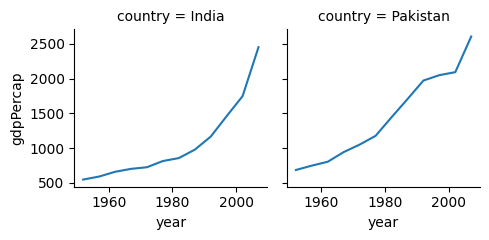

In [53]:
sns.relplot(data = INPK , x = "year" , y = "gdpPercap" , kind = "line" , col = "country", height = 2.5 )

In [63]:
Asia = df[df["continent"] == "Asia"]

In [64]:
Asia  = Asia.pivot(index = "country" , columns = "year" , values = "lifeExp")

<Axes: xlabel='year', ylabel='country'>

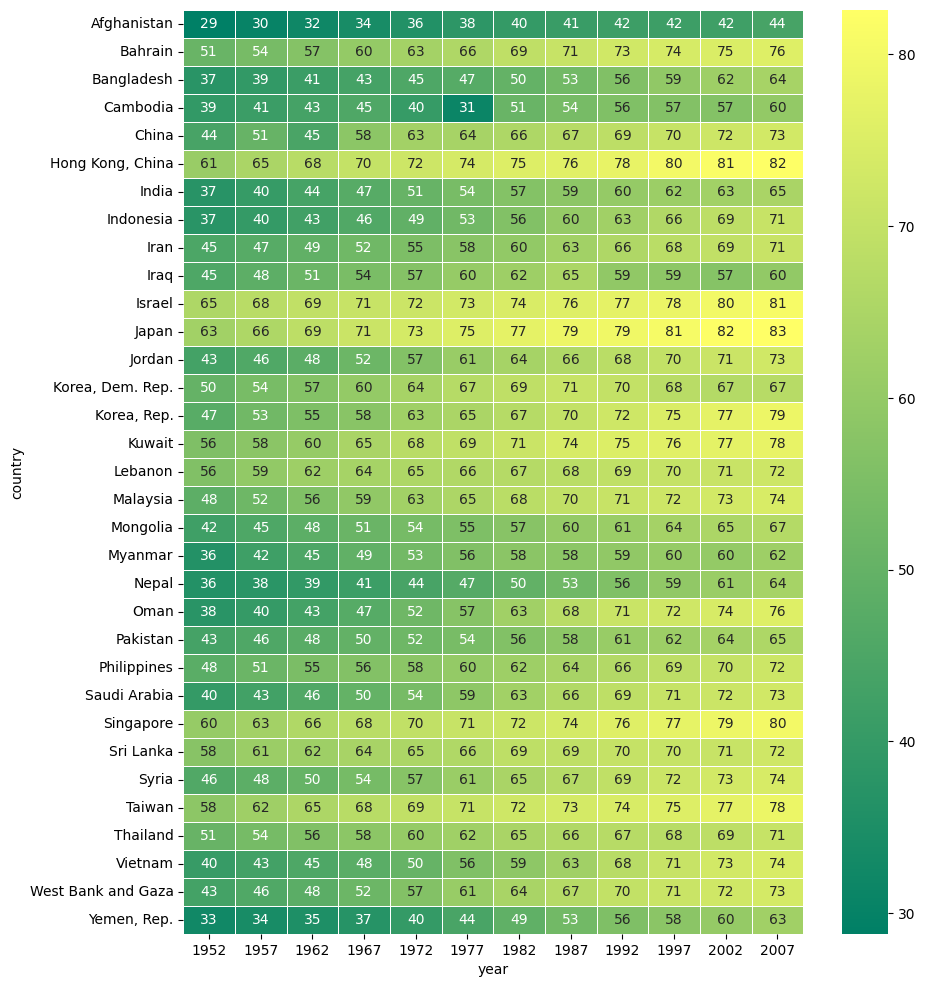

In [71]:
plt.figure(figsize = (10,12))
sns.heatmap(data = Asia , annot = True , cmap = "summer" , linewidth = 0.7)

In [102]:
df.head(3)

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No


In [103]:
df.drop(columns = ["city"] , inplace =True)

In [104]:
df['has_covid'] = df['has_covid'].map({'Yes': 1, 'No': 0})

In [105]:
X_train , X_test , y_train , y_test = train_test_split(df.iloc[:,0:4] , df.iloc[:,-1] , test_size = 0.25, random_state = 42)

In [106]:
df.isnull().sum()

age           0
gender        0
fever        10
cough         0
has_covid     0
dtype: int64

In [156]:
tr1 = ColumnTransformer(transformers=[
    ("fever_imputer", SimpleImputer(), [2]), 
    ("encoded", OrdinalEncoder(categories=[["Mild", "Strong"]]), [3]), 
    ("OHE", OneHotEncoder(drop="first", sparse_output=False), [1])
], remainder="passthrough")

In [165]:
tr2 = ColumnTransformer([
    ('scale', MinMaxScaler(), [0, 3]) # Only scale the continuous features: fever and age
], remainder="passthrough")

In [166]:
tr3 =  DecisionTreeClassifier(random_state=42)   # this prevents Decission tree from over fitting 

In [167]:
pipe = Pipeline([
("one", tr1),
("two" , tr2),
("three" , tr3)   
])

In [168]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('one', ...), ('two', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('fever_imputer', ...), ('encoded', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [169]:
y_pred = pipe.predict(X_test)

In [170]:
y_pred

array([0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1])

In [173]:
from sklearn.metrics import accuracy_score

In [174]:
accuracy_score(y_test, y_pred)

0.4